# Mini Projects: CartPole, FrozenLake, Q-learning, and DQN

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement Q-learning algorithm
- Apply Q-learning to FrozenLake environment
- Apply Q-learning to CartPole environment (with state discretization)
- Understand Deep Q-Network (DQN) concepts
- Train and evaluate RL agents on classic environments

## 🔗 Prerequisites

- ✅ OpenAI Gym setup
- ✅ Understanding of states, actions, rewards
- ✅ Epsilon-Greedy exploration strategy
- ✅ Python knowledge (functions, classes, loops, dictionaries)
- ✅ NumPy knowledge
- ✅ Basic understanding of neural networks (for DQN section)

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 1**:
- Mini projects: applying RL in games like CartPole and FrozenLake, implementing Q-learning and DQN

---

## Introduction

This notebook combines multiple mini projects:
1. **Q-learning on FrozenLake**: Classic grid-world problem with discrete states
2. **Q-learning on CartPole**: Continuous state space requiring discretization
3. **DQN Introduction**: Deep reinforcement learning for high-dimensional states

These projects demonstrate practical RL applications on classic benchmark environments.

## Lesson Brief

This lesson gives students a first practical bridge from small theory examples to recognizable RL tasks.

They will see how the same core ideas appear in environments like FrozenLake and CartPole, even when the implementation details become harder.

Why this matters: students often need one notebook that says, "This is what the theory looks like in a real benchmark."

This lesson is meant to increase confidence before later units go deeper.

## Recommended YouTube Video

To reinforce this lesson, watch **Johnny Code - "Simply Explaining Deep Q-Learning/Deep Q-Network (DQN)"**:
[Watch on YouTube](https://www.youtube.com/watch?v=EUrWGTCGzlA)

Why this pick:
- Clear English accent and step-by-step coding explanation.
- Connects FrozenLake, epsilon-greedy, Q-tables, and DQN in one practical example.
- Good bridge from simple benchmark tasks to deeper RL methods.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Replay buffer: stored experiences for reuse.
- Target network: stabilizes targets.
- Mini-batch: a small training sample.
- Approximator: a neural network replacing the table.

### Quick Check
- Why does DQN need replay?
- Why use a target network?
- What does DQN solve that tabular methods cannot?

### Common Mistakes
- Focusing on network code but missing the algorithm idea.
- Thinking deep RL is unrelated to Q-learning.
- Ignoring stability as the main challenge.


## What you should learn from this notebook

This notebook is the bridge from Unit 1 theory to small practical experiments.

By the end, you should be able to:

- connect MDP ideas to simple environments
- understand the shape of a Q-learning workflow
- see why FrozenLake fits tabular RL well
- understand why CartPole is harder for tabular methods
- treat DQN as a preview of Unit 3, not as the main goal of Unit 1


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.
# Torch is included because the final DQN preview cell imports it explicitly.

# Line magic: Jupyter/IPython directive for this line only.
%pip install torch "gymnasium[classic_control]" numpy matplotlib -q
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt
# Import names from a package/module into the notebook kernel namespace.
import gymnasium as gym
# Import names from a package/module into the notebook kernel namespace.
import random
# Import names from a package/module into the notebook kernel namespace.
from collections import defaultdict

# Print text to the notebook cell output (console).
print("✅ Libraries imported!")
# Print text to the notebook cell output (console).
print("\nMini Projects: CartPole, FrozenLake, Q-learning, and DQN")
# Print text to the notebook cell output (console).
print("=" * 60)


You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


✅ Libraries imported!

Mini Projects: CartPole, FrozenLake, Q-learning, and DQN


## Part 1: Q-Learning Algorithm Implementation


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Print text to the notebook cell output (console).
print("=" * 60)
# Print text to the notebook cell output (console).
print("Part 1: Q-Learning Algorithm Implementation")
# Print text to the notebook cell output (console).
print("=" * 60)


# Define function `q_learning_update`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def q_learning_update(q_table, state, action, reward, next_state, alpha, gamma):
    # Assign/update a variable used later in this cell or in other cells.
    best_next = np.max(q_table[next_state])
    # Assign/update a variable used later in this cell or in other cells.
    td_target = reward + gamma * best_next
    # Assign/update a variable used later in this cell or in other cells.
    td_error = td_target - q_table[state, action]
    # Assign/update a variable used later in this cell or in other cells.
    q_table[state, action] += alpha * td_error
    # Return a value from this function to its caller.
    return q_table[state, action]


# Assign/update a variable used later in this cell or in other cells.
q_demo = np.zeros((5, 4))
# Assign/update a variable used later in this cell or in other cells.
updated_value = q_learning_update(
    # Execute: q_demo,
    q_demo,
    # Create or choose a variable used in the Bellman warm-up demo.
    state=2,
    # Assign/update a variable used later in this cell or in other cells.
    action=1,
    # Unpack the one-step model output from transition(state, action).
    reward=10,
    # Unpack the one-step model output from transition(state, action).
    next_state=3,
    # Assign/update a variable used later in this cell or in other cells.
    alpha=0.1,
    # Assign/update a variable used later in this cell or in other cells.
    gamma=0.9,
# Close the parentheses opened earlier (end this function call / grouping).
)

# Print text to the notebook cell output (console).
print("A single Q-learning update example:")
# Print text to the notebook cell output (console).
print("Updated Q[2, 1] =", round(updated_value, 3))
# Print text to the notebook cell output (console).
print("\nCore idea:")
# Print text to the notebook cell output (console).
print("Q-learning moves the current estimate toward reward + discounted best future value.")


Part 1: Q-Learning Algorithm Implementation
A single Q-learning update example:
Updated Q[2, 1] = 1.0

Core idea:
Q-learning moves the current estimate toward reward + discounted best future value.


## Part 2: Q-Learning on FrozenLake


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Print text to the notebook cell output (console).
print("\n" + "=" * 60)
# Print text to the notebook cell output (console).
print("Part 2: Q-Learning on FrozenLake")
# Print text to the notebook cell output (console).
print("=" * 60)

# Assign/update a variable used later in this cell or in other cells.
env = gym.make("FrozenLake-v1", is_slippery=False)
# Assign/update a variable used later in this cell or in other cells.
q_table = np.zeros((env.observation_space.n, env.action_space.n))
# Assign/update a variable used later in this cell or in other cells.
alpha = 0.1
# Assign/update a variable used later in this cell or in other cells.
gamma = 0.95
# Assign/update a variable used later in this cell or in other cells.
epsilon = 1.0
# Assign/update a variable used later in this cell or in other cells.
epsilon_min = 0.05
# Assign/update a variable used later in this cell or in other cells.
epsilon_decay = 0.995
# Unpack the one-step model output from transition(state, action).
rewards = []

# Loop header: repeat the indented block for each item in the iterable.
for episode in range(1200):
    # Assign/update a variable used later in this cell or in other cells.
    state, info = env.reset(seed=episode)
    # Assign/update a variable used later in this cell or in other cells.
    total_reward = 0
    # Loop header: repeat the indented block for each item in the iterable.
    for _ in range(100):
        # Branch: only run the next indented lines when this condition is true.
        if np.random.rand() < epsilon:
            # Assign/update a variable used later in this cell or in other cells.
            action = env.action_space.sample()
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Assign/update a variable used later in this cell or in other cells.
            action = int(np.argmax(q_table[state]))

        # Unpack the one-step model output from transition(state, action).
        next_state, reward, terminated, truncated, info = env.step(action)
        # Execute: q_learning_update(q_table, state, action, reward, next_state, alpha, gamma)
        q_learning_update(q_table, state, action, reward, next_state, alpha, gamma)
        # Create or choose a variable used in the Bellman warm-up demo.
        state = next_state
        # Assign/update a variable used later in this cell or in other cells.
        total_reward += reward
        # Branch: only run the next indented lines when this condition is true.
        if terminated or truncated:
            # Exit the nearest enclosing loop immediately.
            break

    # Append one value to a list (mutates the list in place).
    rewards.append(total_reward)
    # Assign/update a variable used later in this cell or in other cells.
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

# Execute: env.close()
env.close()

# Assign/update a variable used later in this cell or in other cells.
recent_success = np.mean(rewards[-100:])
# Print text to the notebook cell output (console).
print("FrozenLake Q-table shape:", q_table.shape)
# Print text to the notebook cell output (console).
print("Average reward over last 100 episodes:", round(recent_success, 3))
# Print text to the notebook cell output (console).
print("Final epsilon:", round(epsilon, 3))
# Print text to the notebook cell output (console).
print("\nWhy this example matters:")
# Print text to the notebook cell output (console).
print("FrozenLake has a small discrete state space, so tabular Q-learning is a natural fit.")
# Print text to the notebook cell output (console).
print("With enough episodes and decaying exploration, the agent should solve the deterministic map consistently.")



Part 2: Q-Learning on FrozenLake


FrozenLake Q-table shape: (16, 4)
Average reward over last 100 episodes: 0.96
Final epsilon: 0.05

Why this example matters:
FrozenLake has a small discrete state space, so tabular Q-learning is a natural fit.
With enough episodes and decaying exploration, the agent should solve the deterministic map consistently.


## Part 3: Q-Learning on CartPole (with State Discretization)


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Print text to the notebook cell output (console).
print("\n" + "=" * 60)
# Print text to the notebook cell output (console).
print("Part 3: Q-Learning on CartPole (with State Discretization)")
# Print text to the notebook cell output (console).
print("=" * 60)

# Assign/update a variable used later in this cell or in other cells.
env = gym.make("CartPole-v1")
# Assign/update a variable used later in this cell or in other cells.
obs, info = env.reset(seed=42)

# Print text to the notebook cell output (console).
print("One CartPole observation:", obs)
# Print text to the notebook cell output (console).
print("Observation dimension:", len(obs))
# Print text to the notebook cell output (console).
print("Action space:", env.action_space)

# Execute: env.close()
env.close()

# Print text to the notebook cell output (console).
print("\nWhy CartPole is harder than FrozenLake:")
# Print text to the notebook cell output (console).
print("- CartPole observations are continuous, not small discrete state IDs.")
# Print text to the notebook cell output (console).
print("- A plain Q-table does not directly fit this representation.")
# Print text to the notebook cell output (console).
print("- One workaround is discretization, but that can be crude and inefficient.")
# Print text to the notebook cell output (console).
print("- This motivates neural-network approaches such as DQN later.")



Part 3: Q-Learning on CartPole (with State Discretization)
One CartPole observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation dimension: 4
Action space: Discrete(2)

Why CartPole is harder than FrozenLake:
- CartPole observations are continuous, not small discrete state IDs.
- A plain Q-table does not directly fit this representation.
- One workaround is discretization, but that can be crude and inefficient.
- This motivates neural-network approaches such as DQN later.


## Part 4: Introduction to Deep Q-Network (DQN)


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [5]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Print text to the notebook cell output (console).
print("\n" + "=" * 60)
# Print text to the notebook cell output (console).
print("Part 4: Introduction to Deep Q-Network (DQN)")
# Print text to the notebook cell output (console).
print("=" * 60)

# Print text to the notebook cell output (console).
print("\nDQN Overview:")
# Print text to the notebook cell output (console).
print(" - Uses neural network to approximate Q-function (instead of Q-table)")
# Print text to the notebook cell output (console).
print(" - Handles high-dimensional state spaces (e.g., images)")
# Print text to the notebook cell output (console).
print(" - Key innovations:")
# Print text to the notebook cell output (console).
print(" 1. Experience Replay: Store transitions, sample randomly for training")
# Print text to the notebook cell output (console).
print(" 2. Target Network: Separate network for stable Q-targets")
# Print text to the notebook cell output (console).
print(" 3. Neural Network: Approximate Q(s,a) for continuous/ high-dim states")

# Print text to the notebook cell output (console).
print("\nDQN Architecture:")
# Print text to the notebook cell output (console).
print(" Input: State (e.g., image, observation vector)")
# Print text to the notebook cell output (console).
print(" Network: Fully connected or CNN layers")
# Print text to the notebook cell output (console).
print(" Output: Q-values for each action")

# Print text to the notebook cell output (console).
print("\nDQN vs Q-Learning:")
# Print text to the notebook cell output (console).
print(" Q-Learning:")
# Print text to the notebook cell output (console).
print(" - Uses Q-table (discrete states only)")
# Print text to the notebook cell output (console).
print(" - Limited to small state spaces")
# Print text to the notebook cell output (console).
print(" - Fast for tabular problems")
# Print text to the notebook cell output (console).
print(" DQN:")
# Print text to the notebook cell output (console).
print(" - Uses neural network (continuous/high-dim states)")
# Print text to the notebook cell output (console).
print(" - Scales to complex problems (e.g., Atari games)")
# Print text to the notebook cell output (console).
print(" - Requires more computation and tuning")

# Print text to the notebook cell output (console).
print("\nDQN Algorithm (High-Level):")
# Print text to the notebook cell output (console).
print(" 1. Initialize Q-network and target network")
# Print text to the notebook cell output (console).
print(" 2. For each episode:")
# Print text to the notebook cell output (console).
print(" a. Observe state")
# Print text to the notebook cell output (console).
print(" b. Choose action using epsilon-greedy (using Q-network)")
# Print text to the notebook cell output (console).
print(" c. Take action, store transition in replay buffer")
# Print text to the notebook cell output (console).
print(" d. Sample batch from replay buffer")
# Print text to the notebook cell output (console).
print(" e. Compute targets using target network")
# Print text to the notebook cell output (console).
print(" f. Update Q-network using loss: (Q(s,a) - target)^2")
# Print text to the notebook cell output (console).
print(" g. Periodically update target network")

# Print text to the notebook cell output (console).
print("\nNote: Full DQN implementation will be covered in Unit 3 (Deep RL)")
# Print text to the notebook cell output (console).
print("This is an introduction to the concepts.")

# Print text to the notebook cell output (console).
print("\n✅ DQN introduction complete!")



Part 4: Introduction to Deep Q-Network (DQN)

DQN Overview:
 - Uses neural network to approximate Q-function (instead of Q-table)
 - Handles high-dimensional state spaces (e.g., images)
 - Key innovations:
 1. Experience Replay: Store transitions, sample randomly for training
 2. Target Network: Separate network for stable Q-targets
 3. Neural Network: Approximate Q(s,a) for continuous/ high-dim states

DQN Architecture:
 Input: State (e.g., image, observation vector)
 Network: Fully connected or CNN layers
 Output: Q-values for each action

DQN vs Q-Learning:
 Q-Learning:
 - Uses Q-table (discrete states only)
 - Limited to small state spaces
 - Fast for tabular problems
 DQN:
 - Uses neural network (continuous/high-dim states)
 - Scales to complex problems (e.g., Atari games)
 - Requires more computation and tuning

DQN Algorithm (High-Level):
 1. Initialize Q-network and target network
 2. For each episode:
 a. Observe state
 b. Choose action using epsilon-greedy (using Q-network)


## Preview Only: Why DQN appears next

At this point in the course, the goal is **not** to master deep RL yet.

This section is only a preview showing why DQN becomes necessary:

- CartPole observations are continuous
- tabular Q-learning does not scale well here
- neural networks can approximate action values from raw observations

Full DQN treatment belongs to Unit 3.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


Episode   0 | Avg reward (last 30): 14.0 | ε=0.995


Episode  30 | Avg reward (last 30): 25.0 | ε=0.856


Episode  60 | Avg reward (last 30): 25.5 | ε=0.737


Episode  90 | Avg reward (last 30): 20.3 | ε=0.634
Episode 120 | Avg reward (last 30): 18.3 | ε=0.545


Episode 150 | Avg reward (last 30): 17.6 | ε=0.469


Episode 180 | Avg reward (last 30): 44.3 | ε=0.404


Episode 210 | Avg reward (last 30): 44.0 | ε=0.347


Episode 240 | Avg reward (last 30): 51.6 | ε=0.299


Episode 270 | Avg reward (last 30): 77.1 | ε=0.257


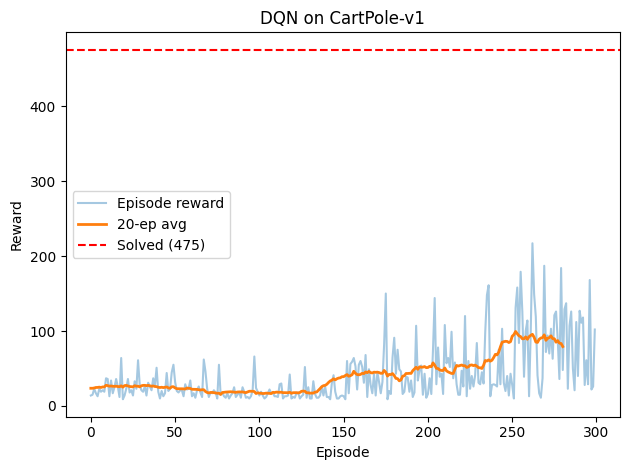

In [6]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Import names from a package/module into the notebook kernel namespace.
import torch, torch.nn as nn, torch.optim as optim
# Import names from a package/module into the notebook kernel namespace.
import gymnasium as gym
# Import names from a package/module into the notebook kernel namespace.
import numpy as np, random, collections, matplotlib.pyplot as plt

# Call a PyTorch API (tensor/module/training-related).
torch.manual_seed(42); np.random.seed(42)

# Assign/update a variable used later in this cell or in other cells.
env = gym.make('CartPole-v1')

# ── DQN Network ──────────────────────────────────────────────────────────
# Define class `DQN`: groups methods/attributes for one concept; see methods in the indented block.
class DQN(nn.Module):
    # Define function `__init__`: parameters in parentheses; the indented body below implements its behavior step-by-step.
    def __init__(self, obs=4, act=2):
        # Execute: super().__init__()
        super().__init__()
        # Assign/update a variable used later in this cell or in other cells.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(obs,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, act)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Define function `forward`: parameters in parentheses; the indented body below implements its behavior step-by-step.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy_net = DQN(); target_net = DQN()
# Execute: target_net.load_state_dict(policy_net.state_dict())
target_net.load_state_dict(policy_net.state_dict())
# Assign/update a variable used later in this cell or in other cells.
opt     = optim.Adam(policy_net.parameters(), lr=1e-3)
# Assign/update a variable used later in this cell or in other cells.
memory  = collections.deque(maxlen=10000)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; EPS = 1.0; EPS_MIN = 0.05; EPS_DECAY = 0.995
# Assign/update a variable used later in this cell or in other cells.
BATCH   = 64; rewards_ep = []

# Loop header: repeat the indented block for each item in the iterable.
for episode in range(300):
    # Assign/update a variable used later in this cell or in other cells.
    obs,_ = env.reset(); total_r = 0
    # Loop header: repeat the indented block for each item in the iterable.
    for t in range(500):
        # Branch: only run the next indented lines when this condition is true.
        if random.random() < EPS:
            # Assign/update a variable used later in this cell or in other cells.
            action = env.action_space.sample()
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Context manager: setup/teardown around the indented block (files, locks, env).
            with torch.no_grad():
                # Assign/update a variable used later in this cell or in other cells.
                action = policy_net(torch.tensor(obs).float().unsqueeze(0)).argmax().item()
        # Assign/update a variable used later in this cell or in other cells.
        obs2, r, done, trunc, _ = env.step(action)
        # Append one value to a list (mutates the list in place).
        memory.append((obs, action, r, obs2, done or trunc))
        # Assign/update a variable used later in this cell or in other cells.
        obs = obs2; total_r += r
        # ── Train ────────────────────────────────────────────────────────
        # Branch: only run the next indented lines when this condition is true.
        if len(memory) >= BATCH:
            # Assign/update a variable used later in this cell or in other cells.
            batch = random.sample(memory, BATCH)
            # Assign/update a variable used later in this cell or in other cells.
            s,a,r_b,s2,d = zip(*batch)
            # Assign/update a variable used later in this cell or in other cells.
            S=torch.tensor(np.array(s)).float(); A=torch.tensor(a).long()
            # Assign/update a variable used later in this cell or in other cells.
            R=torch.tensor(r_b).float(); S2=torch.tensor(np.array(s2)).float()
            # Assign/update a variable used later in this cell or in other cells.
            D=torch.tensor(d).float()
            # Assign/update a variable used later in this cell or in other cells.
            Q_pred = policy_net(S).gather(1,A.unsqueeze(1)).squeeze()
            # Context manager: setup/teardown around the indented block (files, locks, env).
            with torch.no_grad():
                # Assign/update a variable used later in this cell or in other cells.
                Q_next = target_net(S2).max(1)[0]
            # Assign/update a variable used later in this cell or in other cells.
            Q_target = R + GAMMA*Q_next*(1-D)
            # Assign/update a variable used later in this cell or in other cells.
            loss = nn.MSELoss()(Q_pred, Q_target)
            # Execute: opt.zero_grad(); loss.backward(); opt.step()
            opt.zero_grad(); loss.backward(); opt.step()
        # Branch: only run the next indented lines when this condition is true.
        if done or trunc: break
    # Assign/update a variable used later in this cell or in other cells.
    EPS = max(EPS*EPS_DECAY, EPS_MIN)
    # Append one value to a list (mutates the list in place).
    rewards_ep.append(total_r)
    # Branch: only run the next indented lines when this condition is true.
    if episode%50==0: target_net.load_state_dict(policy_net.state_dict())
    # Branch: only run the next indented lines when this condition is true.
    if episode%30==0: print(f"Episode {episode:3d} | Avg reward (last 30): {np.mean(rewards_ep[-30:]):.1f} | ε={EPS:.3f}")

# Execute: env.close()
env.close()
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.plot(rewards_ep, alpha=0.4, label="Episode reward")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.plot(np.convolve(rewards_ep, np.ones(20)/20, 'valid'), label="20-ep avg", lw=2)
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.title("DQN on CartPole-v1"); plt.xlabel("Episode"); plt.ylabel("Reward")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.axhline(475, color='red', linestyle='--', label="Solved (475)"); plt.legend()
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.tight_layout(); plt.show()


## Summary

This notebook connected Unit 1 theory to small practical experiments.

### Main takeaways

- Q-learning updates action values from reward and estimated future value.
- FrozenLake is a friendly first environment for tabular RL.
- CartPole is harder because the observation space is continuous.
- DQN is introduced here only as a preview of the next level of RL methods.

### What should be mastered now

At the end of Unit 1, students should be comfortable with:

- the RL interaction loop
- states, actions, rewards, and policies
- simple tabular updates
- why some environments are easy for tables and others are not

### What can wait until later

The details of replay buffers, target networks, and deep RL training stability belong to Unit 3.

## 📚 References & Further Reading

**Papers:**
- Watkins & Dayan (1992) — [Q-Learning](https://link.springer.com/article/10.1007/BF00992698)
- Mnih et al. (2015) — [DQN: Human-level control via deep RL](https://www.nature.com/articles/nature14236)
- Van Hasselt et al. (2016) — [Double DQN](https://arxiv.org/abs/1509.06461)

**OpenAI Gym:** [Gymnasium Documentation](https://gymnasium.farama.org/)

**State-of-the-Art:** DQN variants power game-playing AI and robotics controllers at Google DeepMind.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


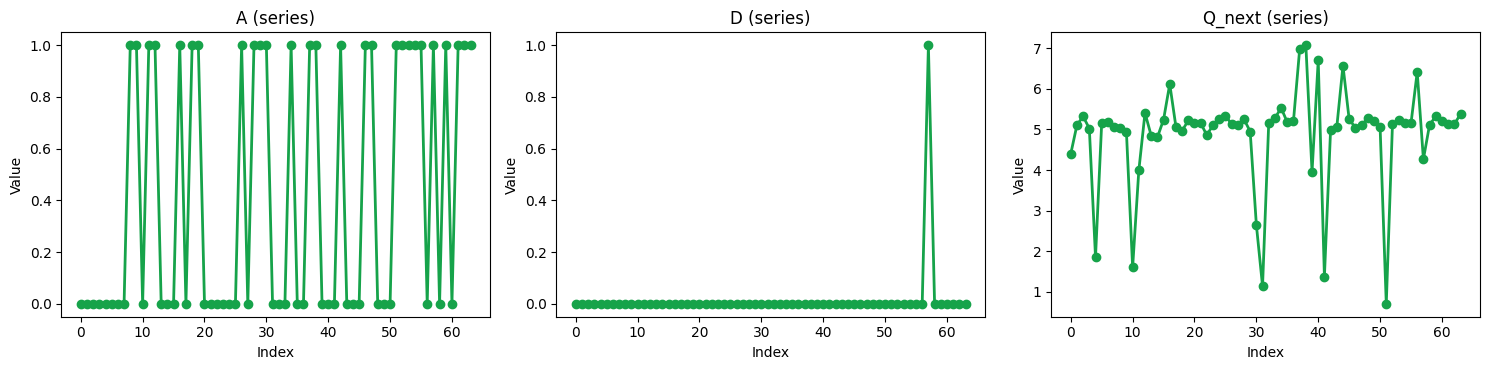

In [7]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Define function `_is_number`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Define function `_as_numeric_dict`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Define function `_as_numeric_array`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # Execute: "functions": sum(callable(value) for value in globals().values()),
        "functions": sum(callable(value) for value in globals().values()),
        # Execute: "classes": sum(isinstance(value, type) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # Execute: "numeric vars": sum(_is_number(value) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_title("Notebook artifact summary")
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # Configure a subplot axis (limits, ticks, labels, or artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticks(range(len(values)))
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (dict)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (series)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xlabel("Index")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Mini-projects help students connect theory to practice by showing how environment choice, algorithm choice, and debugging fit together.

**If students remember one idea:** A project is not only about getting a score. It is about explaining why a method fits a task and how to evaluate it.

**Quick check before moving on:**
- Can you explain why one project may suit tabular methods while another may need deep RL?
- Can you describe what you would monitor while testing a simple RL mini-project?

**Bridge to the next step:** This closes Unit 1 and prepares students for classical prediction and control algorithms in Unit 2.
